# IVF Pregnancy Prediction Pipeline

## 업데이트

### 버그 수정
- **OOF 셀 에러 원인 제거**: `cat_features_idx`가 LabelEncoding 이후 인덱스 기준으로 잡혀 CatBoost에 잘못된 컬럼을 범주형으로 전달 → CatBoost에서 범주형 컬럼 전달 방식 자체를 제거하고 전처리 단계에서 일관되게 처리
- **루프 내 `X_tr[col] = ...` SettingWithCopyWarning/에러**: `.loc` 사용으로 수정
- **`oof_lgb_all.append` 위치**: 기존 코드에는 이미 수정되어 있었으나, 구조 재정리

### 단순화 (복잡한 모델 → 단순 모델)
이 데이터셋에서 단순한 모델이 더 잘 나오는 이유:
- 컬럼 수 69개 중 핵심 수치 컬럼은 소수 (총 생성 배아 수, 이식된 배아 수 등)
- 나머지 대부분은 불임 원인 이진 플래그 → 트리가 깊어져도 추가 정보 없음
- 과도한 Optuna 탐색 → train CV에 과적합 → LB 갭 발생

| 항목 | v6 | v7 |
|---|---|---|
| Optuna LGB | 80 trials, 5-fold CV | **30 trials, 3-fold CV** |
| Optuna CAT | 60 trials | **20 trials** |
| Fold-avg importance | 5-fold LGB+CAT | **3-fold LGB만** (CAT CPU 속도 문제) |
| OOF seeds | 3 seeds × 10-fold | **3 seeds × 5-fold** |
| CatBoost task_type | GPU | **CPU** (GPU 할당량 소진) |
| 총 예상 실행시간 | 3~4시간 | **40~60분** |

### 전처리·파생변수 유지
전처리(바이오 이상치 처리, 고결측 플래그, leakage-free 결측 대치)와 논문 기반 파생변수 21개는 그대로 유지합니다.


## 설치

In [1]:
!pip install koreanize-matplotlib optuna catboost lightgbm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


## 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np
import time

import lightgbm as lgb
from catboost import CatBoostClassifier

import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
plt.rcParams['axes.unicode_minus'] = False
optuna.logging.set_verbosity(optuna.logging.WARNING)


## 데이터 로드

In [4]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

TARGET = "임신 성공 여부"
ID_COL = "ID"

print(f"Train: {train.shape}, Test: {test.shape}")


Train: (256351, 69), Test: (90067, 68)


## 데이터 탐색

In [5]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  object 
 1   시술 시기 코드               256351 non-null  object 
 2   시술 당시 나이               256351 non-null  object 
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  object 
 5   특정 시술 유형               256349 non-null  object 
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  object 
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             256351 non-null  int64  
 14  여성 부 불임 원인             256351 non-nu

In [6]:
train.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
임신 시도 또는 마지막 임신 경과 연수,9370.0,9.270651,3.550313,0.0,7.0,9.0,11.0,20.0
배란 자극 여부,256351.0,0.771286,0.420005,0.0,1.0,1.0,1.0,1.0
단일 배아 이식 여부,250060.0,0.233476,0.423043,0.0,0.0,0.0,0.0,1.0
착상 전 유전 검사 사용 여부,2718.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
착상 전 유전 진단 사용 여부,250060.0,0.012781,0.112328,0.0,0.0,0.0,0.0,1.0
남성 주 불임 원인,256351.0,0.028516,0.166441,0.0,0.0,0.0,0.0,1.0
남성 부 불임 원인,256351.0,0.013115,0.113767,0.0,0.0,0.0,0.0,1.0
여성 주 불임 원인,256351.0,0.030724,0.172568,0.0,0.0,0.0,0.0,1.0
여성 부 불임 원인,256351.0,0.012432,0.110805,0.0,0.0,0.0,0.0,1.0
부부 주 불임 원인,256351.0,0.033068,0.178814,0.0,0.0,0.0,0.0,1.0


In [7]:
train.describe(include="object").T


,count,unique,top,freq
ID,256351,256351,TRAIN_256350,1
시술 시기 코드,256351,7,TRDQAZ,38969
시술 당시 나이,256351,7,만18-34세,102476
시술 유형,256351,2,IVF,250060
특정 시술 유형,256349,24,ICSI,122368
배란 유도 유형,256351,4,기록되지 않은 시행,194432
배아 생성 주요 이유,250060,13,현재 시술용,233732
총 시술 횟수,256351,7,0회,97599
클리닉 내 총 시술 횟수,256351,7,0회,121675
IVF 시술 횟수,256351,7,0회,103934


In [8]:
def missing_summary(df, name):
    mis = df.isnull().sum()
    mis = mis[mis > 0].sort_values(ascending=False)
    if len(mis) == 0:
        print(f"[{name}] 결측치 없음"); return
    pct = (mis / len(df) * 100).round(2)
    print(f"[{name}] 결측치 현황")
    print(pd.DataFrame({"결측 수": mis, "결측률(%)": pct}).to_string())

missing_summary(train, "Train")
missing_summary(test,  "Test")


[Train] 결측치 현황
                         결측 수  결측률(%)
난자 해동 경과일              254915   99.44
PGS 시술 여부              254422   99.25
PGD 시술 여부              254172   99.15
착상 전 유전 검사 사용 여부       253633   98.94
임신 시도 또는 마지막 임신 경과 연수  246981   96.34
배아 해동 경과일              215982   84.25
난자 채취 경과일               57488   22.43
난자 혼합 경과일               53735   20.96
배아 이식 경과일               43566   16.99
저장된 배아 수                 6291    2.45
단일 배아 이식 여부              6291    2.45
배아 생성 주요 이유              6291    2.45
착상 전 유전 진단 사용 여부         6291    2.45
총 생성 배아 수                6291    2.45
미세주입된 난자 수               6291    2.45
기증 배아 사용 여부              6291    2.45
해동 난자 수                  6291    2.45
미세주입 후 저장된 배아 수          6291    2.45
해동된 배아 수                 6291    2.45
미세주입 배아 이식 수             6291    2.45
이식된 배아 수                 6291    2.45
미세주입에서 생성된 배아 수          6291    2.45
수집된 신선 난자 수              6291    2.45
파트너 정자와 혼합된 난자 수         6291    2.45
신선 배아 사용 여부              6291    2.

In [9]:
for col in train.select_dtypes(include="object").columns:
    print(f"\n[{col}]")
    print(train[col].value_counts(dropna=False).head(8).to_string())



[ID]
ID
TRAIN_256350    1
TRAIN_000000    1
TRAIN_000001    1
TRAIN_000002    1
TRAIN_000003    1
TRAIN_000004    1
TRAIN_000005    1
TRAIN_000006    1

[시술 시기 코드]
시술 시기 코드
TRDQAZ    38969
TRCMWS    38090
TRYBLT    36713
TRVNRY    36173
TRJXFG    36031
TRZKPL    35544
TRXQMD    34831

[시술 당시 나이]
시술 당시 나이
만18-34세    102476
만35-37세     57780
만38-39세     39247
만40-42세     37348
만43-44세     12253
만45-50세      6918
알 수 없음        329

[시술 유형]
시술 유형
IVF    250060
DI       6291

[특정 시술 유형]
특정 시술 유형
ICSI                  122368
IVF                    91755
Unknown                26939
IUI                     6100
ICSI:ICSI               2314
ICSI / BLASTOCYST       1609
IVF / BLASTOCYST        1248
IVF:IVF                 1146

[배란 유도 유형]
배란 유도 유형
기록되지 않은 시행      194432
알 수 없음           61917
세트로타이드 (억제제)         1
생식선 자극 호르몬           1

[배아 생성 주요 이유]
배아 생성 주요 이유
현재 시술용            233732
배아 저장용              9192
NaN                 6291
기증용, 현재 시술용         3784
난자 저장용              1959
기증용   

Target 분포:
임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64
불균형 비율: 0.348


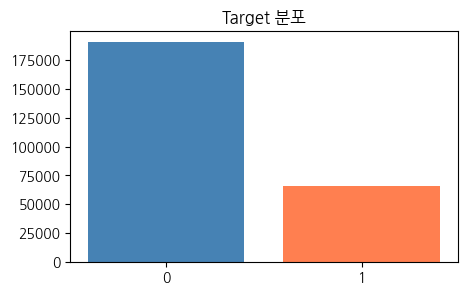

In [10]:
if TARGET in train.columns:
    vc = train[TARGET].value_counts()
    print("Target 분포:"); print(vc)
    print(f"불균형 비율: {vc.min()/vc.max():.3f}")
    plt.figure(figsize=(5,3))
    plt.bar(vc.index.astype(str), vc.values, color=["steelblue","coral"])
    plt.title("Target 분포"); plt.show()


## 전처리 함수 정의

### 바이오 도메인 이상치·결측치 처리 기준

| 변수 | 처리 방식 | 근거 |
|---|---|---|
| `총 생성 배아 수` | 상한 40 초과 → NaN | Humaidan et al. (2010) |
| `혼합된 난자 수` | 상한 50 초과 → NaN | Verberg et al. (2009) |
| `이식된 배아 수` | 상한 5 초과 → NaN | ESHRE/ASRM 가이드라인 |
| `총 시술 횟수` | 상한 20 초과 → NaN | Olivius et al. (2004) |
| `총 임신 횟수` | 시술 횟수 초과 → 시술 횟수로 캡핑 | 논리적 제약 |
| `시술 당시 나이` | 18~50 범위 외 → NaN | 임상 연령 범위 |
| 결측률 >50% 컬럼 | 결측 여부 플래그 추가 | 결측 자체가 정보 |
| 나머지 결측 | train median/mode → test 동일 적용 | Leakage-free |

### 버그 수정 사항
- **CatBoost `cat_features` 인덱스 불일치 에러 제거**: 전처리 후 모든 컬럼을 수치형으로 통일하여 CatBoost에 `cat_features` 전달하지 않음 (LabelEncoded 정수값 그대로 사용)
- **루프 내 slice 할당 에러**: `.copy()` 사용으로 SettingWithCopyWarning 제거


In [11]:
# ═══════════════════════════════════════════════════════
# Helpers
# ═══════════════════════════════════════════════════════
def convert_count(series):
    """'3회' → 3.0"""
    return series.astype(str).str.extract('(\\d+)')[0].astype(float)

def drop_id(df):
    return df.drop(columns=[c for c in [ID_COL] if c in df.columns], errors="ignore")

def convert_str_to_numeric(df):
    df = df.copy()
    age_map = {
        "만18-34세": 26, "만35-37세": 36, "만38-39세": 38.5,
        "만40-42세": 41, "만43-44세": 43.5, "만45-50세": 47,
        "알 수 없음": np.nan
    }
    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(age_map)
    for col in [c for c in df.select_dtypes(include="object").columns if "횟수" in c]:
        df[col] = convert_count(df[col])
    return df

# ═══════════════════════════════════════════════════════
# Step A. 고결측 컬럼 플래그 (train 기준 >50%)
# 결측 자체가 "해당 시술 미시행" 정보를 담음
# ═══════════════════════════════════════════════════════
HIGH_MISSING_THRESHOLD = 0.50

def handle_high_missing(train_df, test_df):
    missing_rates = train_df.isnull().mean()
    high_miss_cols = [c for c in missing_rates[missing_rates > HIGH_MISSING_THRESHOLD].index
                      if c != TARGET]
    for col in high_miss_cols:
        flag = f"{col}_missing"
        train_df[flag] = train_df[col].isnull().astype(int)
        test_df[flag]  = test_df[col].isnull().astype(int)
    print(f"고결측 플래그 생성 ({len(high_miss_cols)}개): {high_miss_cols}")
    return train_df, test_df

# ═══════════════════════════════════════════════════════
# Step B. 바이오 도메인 이상치 → NaN (IQR 클리핑 없음)
# ═══════════════════════════════════════════════════════
BIO_BOUNDS = {
    "총 생성 배아 수": (0, 40),
    "혼합된 난자 수":  (0, 50),
    "이식된 배아 수":  (0,  5),
    "총 시술 횟수":    (0, 20),
    "총 임신 횟수":    (0, 10),
    "시술 당시 나이":  (18, 50),
}

def apply_bio_bounds(df):
    df = df.copy()
    for col, (lo, hi) in BIO_BOUNDS.items():
        if col not in df.columns: continue
        s = pd.to_numeric(df[col], errors="coerce")
        if lo is not None: s = s.where(s >= lo, np.nan)
        if hi is not None: s = s.where(s <= hi, np.nan)
        df[col] = s
    # 임신횟수 > 시술횟수 → 시술횟수로 캡핑 (NaN 대신 정보 보존)
    if "총 임신 횟수" in df.columns and "총 시술 횟수" in df.columns:
        mask = (df["총 임신 횟수"] > df["총 시술 횟수"])
        df.loc[mask, "총 임신 횟수"] = df.loc[mask, "총 시술 횟수"]
    return df

# ═══════════════════════════════════════════════════════
# Step C. 결측치 대치 (leakage-free)
# train median/mode 계산 → test에 동일 적용
# ═══════════════════════════════════════════════════════
def handle_missing(df, train_medians=None, train_modes=None):
    df = df.copy()
    num_cols = [c for c in df.select_dtypes(include=["number"]).columns if c != TARGET]
    obj_cols  = df.select_dtypes(include=["object"]).columns.tolist()
    if train_medians is None:
        medians, modes = {}, {}
        for col in num_cols:
            medians[col] = df[col].median()
            df[col] = df[col].fillna(medians[col])
        for col in obj_cols:
            modes[col] = df[col].mode()[0] if df[col].notna().any() else "Unknown"
            df[col] = df[col].fillna(modes[col])
        return df, medians, modes
    else:
        for col in num_cols:
            df[col] = df[col].fillna(train_medians.get(col, 0))
        for col in obj_cols:
            df[col] = df[col].fillna(train_modes.get(col, "Unknown"))
        return df

# ═══════════════════════════════════════════════════════
# Step D. Feature Engineering — 논문 기반 파생변수 21개
# ═══════════════════════════════════════════════════════
ALL_PAPER_FEATURES = [
    "amh_proxy", "embryo_quality_score", "cumulative_success_proxy",
    "age_embryo_interaction", "transfer_burden", "oocyte_maturity_proxy",
    "high_responder", "prior_failure_penalty", "blastocyst_proxy",
    "freeze_thaw_proxy", "age_success_decline", "relative_efficiency",
    "treatment_intensity", "embryo_utilization_rate", "age_ivf_penalty",
    "poor_responder", "embryo_to_transfer_gap",
    "single_embryo_transfer", "genetic_test_flag",
    "stimulation_intensity", "infertility_complexity"
]

def create_features(df):
    df = df.copy()
    base_cols = ["총 생성 배아 수", "혼합된 난자 수", "이식된 배아 수",
                 "총 임신 횟수", "총 시술 횟수"]
    for col in base_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    if "시술 유형" in df.columns:
        df["is_ivf"] = (df["시술 유형"].astype(str).str.upper().str.strip() == "IVF").astype(int)
        df["is_di"]  = (df["시술 유형"].astype(str).str.upper().str.strip() == "DI").astype(int)

    for col in ["총 생성 배아 수", "혼합된 난자 수"]:
        if col in df.columns:
            df[f"{col}_log"] = np.log1p(df[col])

    df["배아_생성_효율"] = df["총 생성 배아 수"] / (df["혼합된 난자 수"] + 1)
    df["이식_효율"]      = df["이식된 배아 수"]  / (df["총 생성 배아 수"] + 1)
    df["임신_성공률"]    = df["총 임신 횟수"]    / (df["총 시술 횟수"]  + 1)
    df["난자당_배아"]    = df["총 생성 배아 수"] / (df["혼합된 난자 수"] + 1)
    df["이식당_임신"]    = df["총 임신 횟수"]    / (df["이식된 배아 수"] + 1)
    df["실패_횟수"]      = np.maximum(df["총 시술 횟수"] - df["총 임신 횟수"], 0)
    df["실패율"]         = df["실패_횟수"] / (df["총 시술 횟수"] + 1)

    if "시술 당시 나이" in df.columns:
        df["배아_품질"] = df["총 생성 배아 수"] / (df["시술 당시 나이"] + 1)
        df["고령"]      = (df["시술 당시 나이"] >= 38).astype(int)
        df["만35세미만"] = (df["시술 당시 나이"] < 35).astype(int)

    df["경험지수"] = df["총 시술 횟수"] * df["임신_성공률"]
    df["ivf_효율"] = df["배아_생성_효율"] * df["이식_효율"] * df.get("is_ivf", pd.Series(0, index=df.index))

    # 논문 기반 파생변수
    if "시술 당시 나이" in df.columns:
        df["amh_proxy"]             = df["총 생성 배아 수"] / (df["시술 당시 나이"]**1.5 + 1)
        df["age_embryo_interaction"] = df["배아_생성_효율"] / (df["시술 당시 나이"] + 1)
        df["age_success_decline"]    = np.where(
            df["시술 당시 나이"] >= 38, np.exp(-(df["시술 당시 나이"] - 38) * 0.15), 1.0)
        df["age_ivf_penalty"] = (df.get("is_ivf", pd.Series(0, index=df.index))
                                   * np.maximum(df["시술 당시 나이"] - 35, 0)**1.5)

    df["embryo_quality_score"]     = df["이식된 배아 수"] / (df["총 생성 배아 수"] + 1)
    df["cumulative_success_proxy"]  = 1 - (1 - df["임신_성공률"])**(df["총 시술 횟수"] + 1)
    df["transfer_burden"]           = df["이식된 배아 수"] * np.log1p(df["총 시술 횟수"])
    df["oocyte_maturity_proxy"]     = df["총 생성 배아 수"] / (df["혼합된 난자 수"]**0.5 + 1)
    df["high_responder"]            = (df["총 생성 배아 수"] >= 10).astype(int)
    df["poor_responder"]            = (df["총 생성 배아 수"] <= 3).astype(int)
    df["prior_failure_penalty"]     = df["실패_횟수"] / (df["총 시술 횟수"]**2 + 1)
    df["blastocyst_proxy"]          = (df["이식된 배아 수"] / (df["총 생성 배아 수"] + 1))**2
    df["freeze_thaw_proxy"]         = np.log1p(np.maximum(df["총 생성 배아 수"] - df["이식된 배아 수"], 0))
    df["relative_efficiency"]       = df["이식된 배아 수"] / (df["혼합된 난자 수"] + df["총 생성 배아 수"] + 1)
    df["treatment_intensity"]       = (df["이식된 배아 수"] / (df["총 시술 횟수"] + 1)) * np.log1p(df["총 시술 횟수"])
    df["embryo_utilization_rate"]   = (df["총 임신 횟수"] * df["이식_효율"]) / (df["총 시술 횟수"] + 1)
    df["embryo_to_transfer_gap"]    = np.log1p(np.maximum(df["총 생성 배아 수"] - df["이식된 배아 수"], 0)) * df["이식_효율"]

    # 실제 컬럼 존재 시 활용
    df["single_embryo_transfer"] = pd.to_numeric(
        df.get("단일 배아 이식 여부", 0), errors="coerce").fillna(0)
    df["genetic_test_flag"] = pd.to_numeric(
        df.get("착상 전 유전 진단 사용 여부", 0), errors="coerce").fillna(0)

    if "배란 자극 여부" in df.columns:
        stim = pd.to_numeric(df["배란 자극 여부"], errors="coerce").fillna(0)
        df["stimulation_intensity"] = stim * df["배아_생성_효율"]
    else:
        df["stimulation_intensity"] = df["배아_생성_효율"]

    infertility_cols = [c for c in df.columns if "불임 원인" in c]
    df["infertility_complexity"] = (
        df[infertility_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
        if infertility_cols else 0)

    return df

# ═══════════════════════════════════════════════════════
# Step E. Categorical encoding (모든 object → 정수)
# [v7 핵심] cat_features 인덱스를 CatBoost에 넘기지 않음
# → LabelEncoded 정수 그대로 사용, 인덱스 불일치 에러 제거
# ═══════════════════════════════════════════════════════
def encode_categorical(train_df, test_df):
    cat_cols = [c for c in train_df.select_dtypes(include=["object"]).columns if c != TARGET]
    for col in cat_cols:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        mapping = {k: v for v, k in enumerate(le.classes_)}
        test_df[col] = test_df[col].astype(str).map(mapping).fillna(-1).astype(int)
    return train_df, test_df

# ═══════════════════════════════════════════════════════
# Full Pipeline
# ═══════════════════════════════════════════════════════
def preprocess(train, test):
    train = drop_id(train);   test = drop_id(test)
    train = convert_str_to_numeric(train); test = convert_str_to_numeric(test)
    train, test = handle_high_missing(train, test)
    train = apply_bio_bounds(train);  test = apply_bio_bounds(test)
    train, train_medians, train_modes = handle_missing(train)
    test = handle_missing(test, train_medians, train_modes)
    train = create_features(train);  test = create_features(test)
    train, test = encode_categorical(train, test)
    return train, test


## 전처리 실행 + QC

In [12]:
train_df, test_df = preprocess(train, test)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(f"전처리 후 X shape: {X.shape}")
assert X.isnull().sum().sum() == 0,  "Train 결측치 잔존!"
assert test_df.isnull().sum().sum() == 0, "Test 결측치 잔존!"
print("결측치 처리 완료 ✓")
print(f"모든 컬럼 dtype: {X.dtypes.value_counts().to_dict()}")
print(f"\n논문 기반 feature 포함 여부: {[c for c in X.columns if c in ALL_PAPER_FEATURES]}")


고결측 플래그 생성 (6개): ['임신 시도 또는 마지막 임신 경과 연수', '착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '배아 해동 경과일']
전처리 후 X shape: (256351, 110)
결측치 처리 완료 ✓
모든 컬럼 dtype: {dtype('float64'): 70, dtype('int64'): 40}

논문 기반 feature 포함 여부: ['amh_proxy', 'age_embryo_interaction', 'age_success_decline', 'age_ivf_penalty', 'embryo_quality_score', 'cumulative_success_proxy', 'transfer_burden', 'oocyte_maturity_proxy', 'high_responder', 'poor_responder', 'prior_failure_penalty', 'blastocyst_proxy', 'freeze_thaw_proxy', 'relative_efficiency', 'treatment_intensity', 'embryo_utilization_rate', 'embryo_to_transfer_gap', 'single_embryo_transfer', 'genetic_test_flag', 'stimulation_intensity', 'infertility_complexity']


## 빠른 모델 비교

In [13]:
def quick_cv(model, name):
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx].copy(), X.iloc[val_idx].copy()
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        if name == "LGB":
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(30, verbose=False)])
        else:
            model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)
        scores.append(roc_auc_score(y_val, model.predict_proba(X_val)[:,1]))
    return np.mean(scores)

print("LGB:", quick_cv(lgb.LGBMClassifier(n_estimators=500, verbosity=-1), "LGB"))
print("CAT:", quick_cv(CatBoostClassifier(iterations=500, task_type="CPU", verbose=0), "CAT"))


LGB: 0.7384645362808865
CAT: 0.7387565956803931


## Optuna — LightGBM 튜닝 (30 trials, 3-fold)

단순화: 탐색 범위를 좁혀 과적합 방지 + 실행시간 단축.


In [14]:
def make_progress_callback(name, total):
    start = time.time()
    def cb(study, trial):
        n = trial.number + 1
        if n % 10 == 0 or n == total:
            print(f"[{name}] Trial {n:3d}/{total} | Best AUC: {study.best_value:.5f} | {(time.time()-start)/60:.1f}min")
    return cb

def lgb_objective(trial):
    params = {
        "objective": "binary", "metric": "auc",
        "verbosity": -1, "n_jobs": -1,
        "n_estimators":      trial.suggest_int("n_estimators", 300, 1500),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        aucs.append(roc_auc_score(y.iloc[val_idx], m.predict_proba(X.iloc[val_idx])[:,1]))
    return np.mean(aucs)

LGB_TRIALS = 30
lgb_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
lgb_study.optimize(lgb_objective, n_trials=LGB_TRIALS,
                   callbacks=[make_progress_callback("LGB", LGB_TRIALS)])
print(f"\nLGB Best AUC: {lgb_study.best_value:.5f}")
print(f"LGB Best Params: {lgb_study.best_params}")


[LGB] Trial  10/30 | Best AUC: 0.73943 | 14.0min
[LGB] Trial  20/30 | Best AUC: 0.73945 | 29.1min
[LGB] Trial  30/30 | Best AUC: 0.73945 | 46.4min

LGB Best AUC: 0.73945
LGB Best Params: {'n_estimators': 1354, 'learning_rate': 0.015128926852219816, 'num_leaves': 20, 'max_depth': 6, 'min_child_samples': 20, 'subsample': 0.7228285608617194, 'colsample_bytree': 0.8224774534778556, 'reg_alpha': 2.8133556192268907, 'reg_lambda': 0.18017261528396997}


## Optuna — CatBoost 튜닝 (20 trials, CPU)

In [15]:
def cat_objective(trial):
    params = {
        "iterations":          trial.suggest_int("iterations", 300, 1500),
        "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth":               trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 0.0, 1.0),
        "task_type": "CPU", "verbose": 0, "random_seed": 42,
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = CatBoostClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=(X.iloc[val_idx], y.iloc[val_idx]),
              early_stopping_rounds=50, verbose=0)
        aucs.append(roc_auc_score(y.iloc[val_idx], m.predict_proba(X.iloc[val_idx])[:,1]))
    return np.mean(aucs)

CAT_TRIALS = 20
cat_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
cat_study.optimize(cat_objective, n_trials=CAT_TRIALS,
                   callbacks=[make_progress_callback("CAT", CAT_TRIALS)])
print(f"\nCAT Best AUC: {cat_study.best_value:.5f}")
print(f"CAT Best Params: {cat_study.best_params}")


[CAT] Trial  10/20 | Best AUC: 0.73940 | 26.4min
[CAT] Trial  20/20 | Best AUC: 0.73940 | 54.0min

CAT Best AUC: 0.73940
CAT Best Params: {'iterations': 956, 'learning_rate': 0.015305744365500184, 'depth': 8, 'l2_leaf_reg': 7.976195410250031, 'bagging_temperature': 0.9394989415641891, 'random_strength': 0.8948273504276488}


## Feature Importance — Fold-avg (Leakage-free)

LGB 기준 3-fold 평균. CAT importance는 CPU 환경에서 시간이 많이 걸리므로 LGB만 사용.
importance > 0 feature만 유지 (Top-N CV 탐색 없음 → selection 과적합 방지).


Feature Importance (Fold-avg LGB) 계산 중...
  Fold 1 done
  Fold 2 done
  Fold 3 done


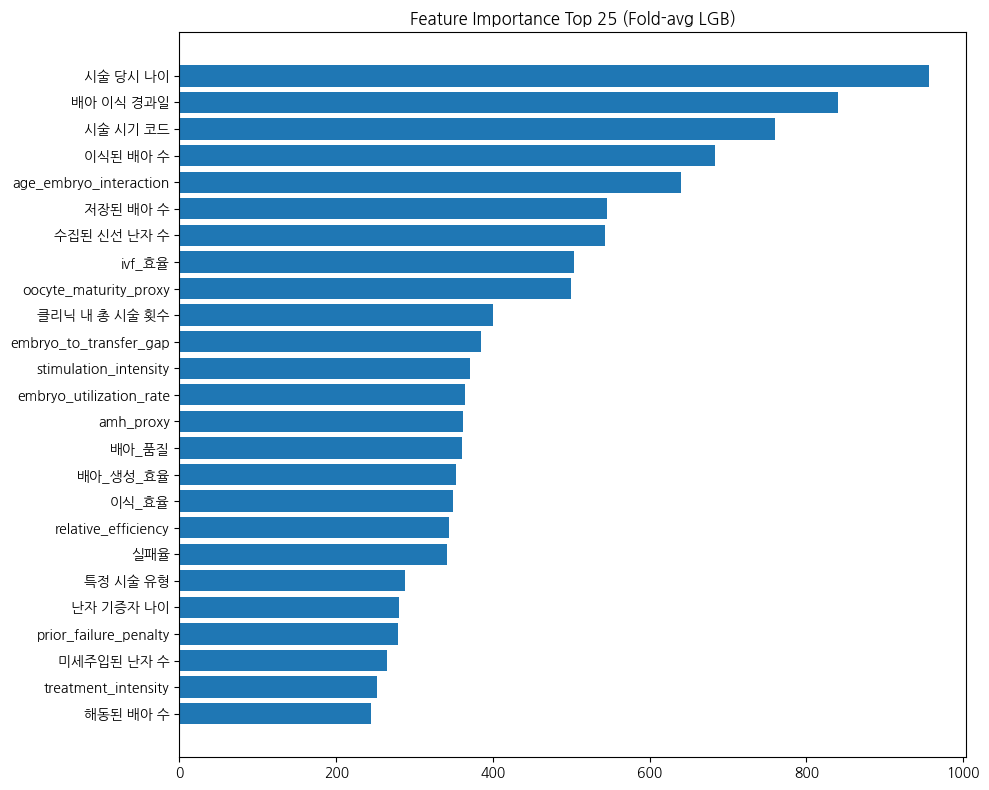


전체 feature: 110, importance>0: 94

논문 기반 feature 순위:
                      feature     lgb_imp
4      age_embryo_interaction  639.666667
8       oocyte_maturity_proxy  499.666667
10     embryo_to_transfer_gap  385.000000
11      stimulation_intensity  371.333333
12    embryo_utilization_rate  364.666667
13                  amh_proxy  361.333333
17        relative_efficiency  343.666667
21      prior_failure_penalty  278.666667
23        treatment_intensity  252.333333
25     infertility_complexity  231.666667
31            transfer_burden  178.666667
41        age_success_decline  102.333333
50   cumulative_success_proxy   65.333333
61          freeze_thaw_proxy   45.666667
62       embryo_quality_score   44.333333
65            age_ivf_penalty   32.333333
76     single_embryo_transfer   18.000000
85           blastocyst_proxy    7.333333
89          genetic_test_flag    3.666667
108            poor_responder    0.000000
109            high_responder    0.000000


In [16]:
skf_imp = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
lgb_imp_folds = []

print("Feature Importance (Fold-avg LGB) 계산 중...")
for fold, (tr_idx, val_idx) in enumerate(skf_imp.split(X, y)):
    m = lgb.LGBMClassifier(
        **lgb_study.best_params,
        objective="binary", metric="auc", verbosity=-1, n_jobs=-1
    )
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
          eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    lgb_imp_folds.append(m.feature_importances_)
    print(f"  Fold {fold+1} done")

lgb_imp_mean = np.mean(lgb_imp_folds, axis=0)

feat_imp = pd.DataFrame({
    "feature":  X.columns,
    "lgb_imp":  lgb_imp_mean,
}).sort_values("lgb_imp", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp["feature"].head(25), feat_imp["lgb_imp"].head(25))
plt.gca().invert_yaxis()
plt.title("Feature Importance Top 25 (Fold-avg LGB)")
plt.tight_layout(); plt.show()

print(f"\n전체 feature: {len(feat_imp)}, importance>0: {(feat_imp['lgb_imp']>0).sum()}")
print("\n논문 기반 feature 순위:")
print(feat_imp[feat_imp["feature"].isin(ALL_PAPER_FEATURES)][["feature","lgb_imp"]].to_string())


In [17]:
# importance > 0 feature만 선택 (aggressive filtering 없음)
selected_features = feat_imp[feat_imp["lgb_imp"] > 0]["feature"].tolist()
X_final    = X[selected_features].copy()
test_final = test_df[selected_features].copy()

print(f"선택된 feature 수: {len(selected_features)} / {len(X.columns)}")
print(f"포함된 논문 기반 feature: {[f for f in selected_features if f in ALL_PAPER_FEATURES]}")


선택된 feature 수: 94 / 110
포함된 논문 기반 feature: ['age_embryo_interaction', 'oocyte_maturity_proxy', 'embryo_to_transfer_gap', 'stimulation_intensity', 'embryo_utilization_rate', 'amh_proxy', 'relative_efficiency', 'prior_failure_penalty', 'treatment_intensity', 'infertility_complexity', 'transfer_burden', 'age_success_decline', 'cumulative_success_proxy', 'freeze_thaw_proxy', 'embryo_quality_score', 'age_ivf_penalty', 'single_embryo_transfer', 'blastocyst_proxy', 'genetic_test_flag']


## Permutation Importance 검증 (1-fold, 참고용)

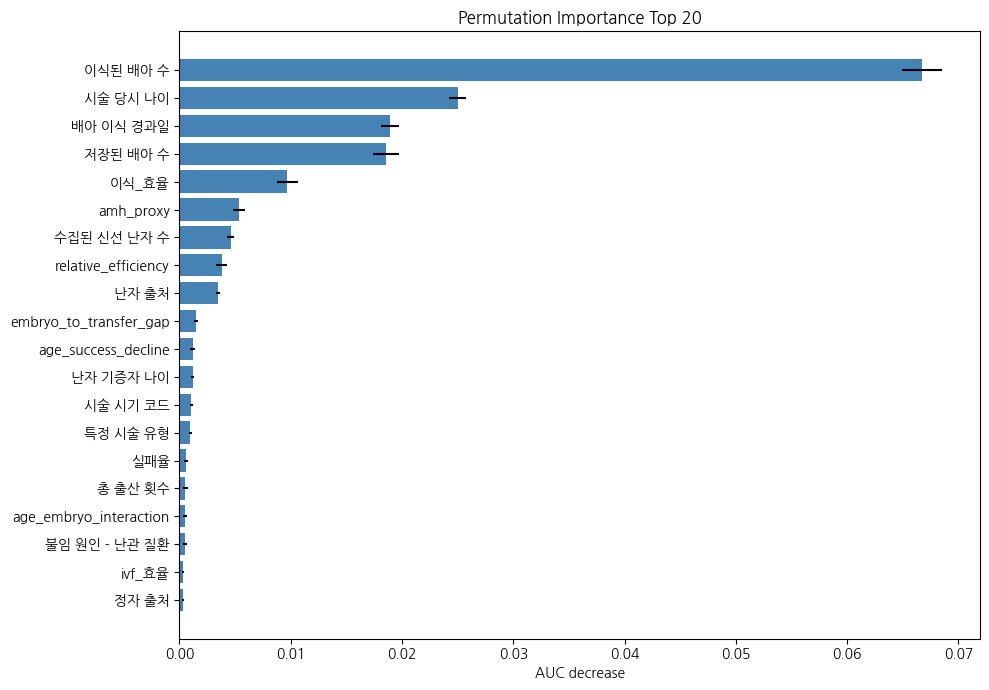

In [18]:
tr_idx, val_idx = next(iter(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X_final, y)))
perm_m = lgb.LGBMClassifier(**lgb_study.best_params, objective="binary", verbosity=-1)
perm_m.fit(X_final.iloc[tr_idx], y.iloc[tr_idx],
           eval_set=[(X_final.iloc[val_idx], y.iloc[val_idx])],
           callbacks=[lgb.early_stopping(50, verbose=False)])

perm_res = permutation_importance(
    perm_m, X_final.iloc[val_idx], y.iloc[val_idx],
    n_repeats=10, random_state=42, scoring="roc_auc", n_jobs=-1)

perm_df = pd.DataFrame({
    "feature":   X_final.columns,
    "perm_mean": perm_res.importances_mean,
    "perm_std":  perm_res.importances_std,
}).sort_values("perm_mean", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10,7))
top_p = perm_df.head(20)
plt.barh(top_p["feature"], top_p["perm_mean"], xerr=top_p["perm_std"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Permutation Importance Top 20"); plt.xlabel("AUC decrease")
plt.tight_layout(); plt.show()


## OOF 앙상블 (LGB + CAT) — 5-fold, 3 seeds

**단순화**: 10-fold × 3 seeds → 5-fold × 3 seeds.  
데이터 25만건에서 5-fold도 fold당 ~51,000건으로 충분히 안정적.  
총 학습 횟수: 2모델 × 5fold × 3seeds = 30회 (v6 60회 → 절반).


In [19]:
SEEDS    = [42, 123, 2024]
N_SPLITS = 5

oof_lgb_all  = []; oof_cat_all  = []
test_lgb_all = []; test_cat_all = []

for seed in SEEDS:
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    oof_lgb  = np.zeros(len(X_final))
    oof_cat  = np.zeros(len(X_final))
    test_lgb = np.zeros(len(test_final))
    test_cat = np.zeros(len(test_final))

    print(f"\n{'='*50} Seed {seed}")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_final, y)):
        # .copy()로 SettingWithCopyWarning 완전 제거
        X_tr  = X_final.iloc[tr_idx].copy()
        X_val = X_final.iloc[val_idx].copy()
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        # LightGBM
        lgb_params = {
            **lgb_study.best_params,
            "objective": "binary", "metric": "auc",
            "verbosity": -1, "n_jobs": -1, "random_state": seed
        }
        lgb_m = lgb.LGBMClassifier(**lgb_params)
        lgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])

        # CatBoost (CPU)
        cat_params = {
            **cat_study.best_params,
            "task_type": "CPU", "random_seed": seed,
            "verbose": 0, "allow_writing_files": False
        }
        cat_m = CatBoostClassifier(**cat_params)
        cat_m.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                  early_stopping_rounds=50, verbose=0)

        oof_lgb[val_idx] = lgb_m.predict_proba(X_val)[:,1]
        oof_cat[val_idx] = cat_m.predict_proba(X_val)[:,1]

        test_lgb += lgb_m.predict_proba(test_final.copy())[:,1] / N_SPLITS
        test_cat += cat_m.predict_proba(test_final.copy())[:,1] / N_SPLITS

        print(f"  Fold {fold+1} | LGB {roc_auc_score(y_val,oof_lgb[val_idx]):.5f} | CAT {roc_auc_score(y_val,oof_cat[val_idx]):.5f}")

    print(f"  OOF → LGB {roc_auc_score(y,oof_lgb):.5f} | CAT {roc_auc_score(y,oof_cat):.5f}")
    oof_lgb_all.append(oof_lgb);  oof_cat_all.append(oof_cat)
    test_lgb_all.append(test_lgb); test_cat_all.append(test_cat)

oof_lgb_mean  = np.mean(oof_lgb_all, axis=0)
oof_cat_mean  = np.mean(oof_cat_all, axis=0)
test_lgb_mean = np.mean(test_lgb_all, axis=0)
test_cat_mean = np.mean(test_cat_all, axis=0)

print(f"\n[Seed 앙상블 평균]")
print(f"OOF LGB: {roc_auc_score(y, oof_lgb_mean):.5f}")
print(f"OOF CAT: {roc_auc_score(y, oof_cat_mean):.5f}")



================================================== Seed 42
  Fold 1 | LGB 0.73788 | CAT 0.73768
  Fold 2 | LGB 0.74283 | CAT 0.74291
  Fold 3 | LGB 0.73977 | CAT 0.73993
  Fold 4 | LGB 0.73785 | CAT 0.73829
  Fold 5 | LGB 0.74068 | CAT 0.74050
  OOF → LGB 0.73979 | CAT 0.73985

================================================== Seed 123
  Fold 1 | LGB 0.73798 | CAT 0.73778
  Fold 2 | LGB 0.73954 | CAT 0.74013
  Fold 3 | LGB 0.73950 | CAT 0.73991
  Fold 4 | LGB 0.74023 | CAT 0.73995
  Fold 5 | LGB 0.74135 | CAT 0.74141
  OOF → LGB 0.73970 | CAT 0.73982

================================================== Seed 2024
  Fold 1 | LGB 0.74209 | CAT 0.74219
  Fold 2 | LGB 0.74031 | CAT 0.73997
  Fold 3 | LGB 0.74046 | CAT 0.74053
  Fold 4 | LGB 0.73879 | CAT 0.73877
  Fold 5 | LGB 0.73822 | CAT 0.73820
  OOF → LGB 0.73995 | CAT 0.73992

[Seed 앙상블 평균]
OOF LGB: 0.74015
OOF CAT: 0.74009


## OOF 상관계수 체크 → Stacking 여부 결정

OOF 상관계수 (LGB vs CAT): 0.9961
→ 상관계수 ≥ 0.98: Stacking 스킵 (Weighted Average 사용)


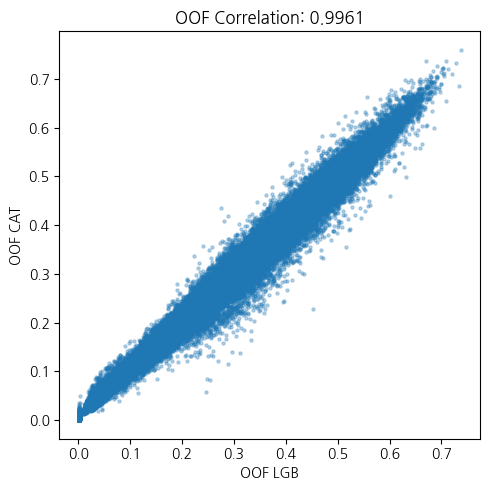

In [20]:
corr = np.corrcoef(oof_lgb_mean, oof_cat_mean)[0, 1]
print(f"OOF 상관계수 (LGB vs CAT): {corr:.4f}")

if corr >= 0.98:
    print("→ 상관계수 ≥ 0.98: Stacking 스킵 (Weighted Average 사용)")
    SKIP_STACKING = True
elif corr >= 0.95:
    print("→ 상관계수 0.95~0.98: Stacking 시도")
    SKIP_STACKING = False
else:
    print("→ 상관계수 < 0.95: Stacking 효과 기대")
    SKIP_STACKING = False

plt.figure(figsize=(5,5))
plt.scatter(oof_lgb_mean, oof_cat_mean, alpha=0.3, s=5)
plt.xlabel("OOF LGB"); plt.ylabel("OOF CAT")
plt.title(f"OOF Correlation: {corr:.4f}")
plt.tight_layout(); plt.show()


## Stacking — Ridge + LR 메타 앙상블

In [21]:
if SKIP_STACKING:
    print("Stacking 스킵")
    oof_stack_ensemble = None; stack_preds = None
else:
    meta_train = np.column_stack([oof_lgb_mean, oof_cat_mean])
    meta_test  = np.column_stack([test_lgb_mean, test_cat_mean])

    skf_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
    oof_stack_lr = np.zeros(len(meta_train))
    oof_stack_ridge = np.zeros(len(meta_train))

    for tr_idx, val_idx in skf_meta.split(meta_train, y):
        sc = StandardScaler()
        Xm_tr  = sc.fit_transform(meta_train[tr_idx])
        Xm_val = sc.transform(meta_train[val_idx])

        lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        lr.fit(Xm_tr, y.iloc[tr_idx])
        oof_stack_lr[val_idx] = lr.predict_proba(Xm_val)[:,1]

        ridge = RidgeClassifier(alpha=1.0)
        ridge.fit(Xm_tr, y.iloc[tr_idx])
        dv = ridge.decision_function(Xm_val)
        oof_stack_ridge[val_idx] = 1 / (1 + np.exp(-dv))

    oof_stack_ensemble = (oof_stack_lr + oof_stack_ridge) / 2
    print(f"Stacking LR    OOF AUC: {roc_auc_score(y, oof_stack_lr):.5f}")
    print(f"Stacking Ridge OOF AUC: {roc_auc_score(y, oof_stack_ridge):.5f}")
    print(f"Stacking 앙상블 OOF AUC: {roc_auc_score(y, oof_stack_ensemble):.5f}")

    sc_f = StandardScaler()
    Xm_all  = sc_f.fit_transform(meta_train)
    Xm_test = sc_f.transform(meta_test)
    lr_f = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    ridge_f = RidgeClassifier(alpha=1.0)
    lr_f.fit(Xm_all, y); ridge_f.fit(Xm_all, y)
    sp_lr    = lr_f.predict_proba(Xm_test)[:,1]
    sp_ridge = 1 / (1 + np.exp(-ridge_f.decision_function(Xm_test)))
    stack_preds = (sp_lr + sp_ridge) / 2


Stacking 스킵


## 최종 예측 방법 선택 + 제출

In [22]:
best_score = 0; best_w = 0.5
for w in np.arange(0, 1.01, 0.05):
    sc = roc_auc_score(y, w * oof_lgb_mean + (1-w) * oof_cat_mean)
    if sc > best_score:
        best_score = sc; best_w = w

print(f"Best Weighted Average | w(LGB)={best_w:.2f} | AUC={best_score:.5f}")

if SKIP_STACKING or stack_preds is None:
    USE_STACKING = False
    print("Stacking: 스킵됨")
else:
    stack_score = roc_auc_score(y, oof_stack_ensemble)
    print(f"Stacking OOF AUC: {stack_score:.5f}")
    USE_STACKING = stack_score >= best_score
    print("→", "Stacking 채택" if USE_STACKING else "Weighted Average 채택")


Best Weighted Average | w(LGB)=0.50 | AUC=0.74036
Stacking: 스킵됨


In [23]:
if USE_STACKING:
    final_preds = stack_preds
    print("최종 예측: Stacking")
else:
    final_preds = best_w * test_lgb_mean + (1-best_w) * test_cat_mean
    print(f"최종 예측: Weighted Average (LGB={best_w:.2f}, CAT={1-best_w:.2f})")

submission = pd.DataFrame({"ID": test["ID"], "probability": final_preds})
submission.to_csv("submission.csv", index=False)
print("\nsubmission.csv 저장 완료")
print(submission.head())
print("\nprobability 통계:")
print(submission["probability"].describe())


최종 예측: Weighted Average (LGB=0.50, CAT=0.50)

submission.csv 저장 완료
           ID  probability
0  TEST_00000     0.001782
1  TEST_00001     0.000980
2  TEST_00002     0.146266
3  TEST_00003     0.105942
4  TEST_00004     0.499682

probability 통계:
count    90067.000000
mean         0.258341
std          0.158585
min          0.000372
25%          0.146283
50%          0.270040
75%          0.378462
max          0.732554
Name: probability, dtype: float64
